# 08 — Synthetic multiplicity dataset

**Purpose:** Train Rashomon models on a synthetic dataset with a known ambiguous region (island), compute predictive variance, Moran's I, and LISA; visualize variance and HH hotspots; report recovery (Precision/Recall/Jaccard) of the ground-truth island; fit a decision tree (HH vs non-HH); run the null experiment.

## 1. Imports and path setup

In [ ]:
import sys
import importlib
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import display_dataset_name, RAW_RESULTS, thesis_output_dirs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import make_split, make_preprocessor
import src.synthetic_data
importlib.reload(src.synthetic_data)
from src.synthetic_data import (
    make_synthetic_multiplicity_dataset,
    make_synth_three_islands_plus_outliers,
    SyntheticGroundTruth,
    SyntheticGT,
)
from src.training_pipeline import run_one_training_run, save_run_artifacts
from analysis.run_analysis import (
    load_meta,
    load_P_test,
    select_rashomon_global,
    run_spatial,
    spatial_analysis,
    run_null,
    pointwise_variance,
    compute_multiplicity_metrics,
)
from analysis.spatial import extract_hh_components

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("synthetic")
K = 25
K_NN = 30
SEED = 42
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

from analysis.cache import load_or_compute_df


## 2. Generate synthetic data

Stable region: two well-separated blobs. Ambiguous island: uniform disk around origin with weak XOR-like P(y=1|x).

Samples: 3000, island (ambiguous): 600, stable: 2400
Features: {'numeric': ['x1', 'x2'], 'categorical': []}


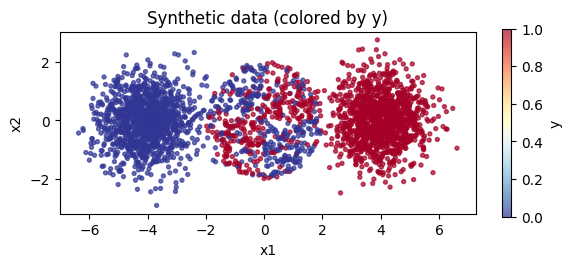

In [2]:
X, y, feature_info, gt = make_synthetic_multiplicity_dataset(
    n_samples=3000,
    p_island=0.2,
    island_delta=0.30,
    random_state=SEED,
)
print(f"Samples: {len(X)}, island (ambiguous): {gt.island_mask.sum()}, stable: {gt.stable_mask.sum()}")
print("Features:", feature_info)

# Plot data colored by target y
plt.figure(figsize=(6, 5))
plt.scatter(X["x1"], X["x2"], c=y, s=8, alpha=0.7, cmap="RdYlBu_r")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic data (colored by y)")
plt.colorbar(label="y", shrink=0.4)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_ground_truth.pdf", bbox_inches="tight")
plt.show()

## 3. Train models and save artifacts

Single split (60/20/20), multiple families (LogReg, RF, GBM, MLP, kNN), top-K by validation Brier. Save to `results/synthetic/seed={SEED}/` so analysis functions can load from run_dir.

In [3]:
preprocessor_factory = lambda fi: make_preprocessor(fi, scale_numeric=True)

split, meta, P_val, P_test, _ = run_one_training_run(
    X=X,
    y=y,
    feature_info=feature_info,
    preprocessor_factory=preprocessor_factory,
    outer_seed=SEED,
    n_candidates_per_family=50,
    test_size=0.2,
    val_size=0.2,
    verbose=1,
)

run_dir = RESULTS_DIR / "synthetic" / f"seed={SEED}"
run_dir.mkdir(parents=True, exist_ok=True)
save_run_artifacts(run_dir, split, meta, P_val, P_test, config={"dataset": "synthetic", "seed": SEED})

# Preprocessed X_test for spatial analysis (same as used inside pipelines)
preprocessor = preprocessor_factory(feature_info)
X_train = X.iloc[split["train"]]
y_train = y.iloc[split["train"]]
preprocessor.fit(X_train, y_train)
X_test_raw = X.iloc[split["test"]]
X_test = preprocessor.transform(X_test_raw)
if hasattr(X_test, "toarray"):
    X_test = np.asarray(X_test)
else:
    X_test = np.asarray(X_test)

print(f"Saved to {run_dir}")
print(f"Candidates: {len(meta)}, test size: {X_test.shape[0]}")

  [LogReg] 50 candidates trained


  [kNN] 50 candidates trained


  [RF] 50 candidates trained


  [GBM] 50 candidates trained


  [MLP] 50 candidates trained
Saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\synthetic\seed=42
Candidates: 250, test size: 600


## 4. Rashomon selection and metrics

Select top-K by validation Brier; compute predictive variance, Moran's I, LISA (HH/LL masks).

In [4]:
n_cand = len(load_meta(run_dir))
K_actual = min(K, n_cand)
spatial = run_spatial(run_dir, X_test, K=K_actual, k=K_NN)
mult = compute_multiplicity_metrics(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], epsilon=0.05)

v = pointwise_variance(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], ddof=0)
HH_mask = spatial["HH_mask"]
LL_mask = spatial["LL_mask"]

print(f"Moran's I: {spatial['moran_i']:.4f}")
print(f"Mean variance: {mult['mean_variance']:.6f}")
print(f"HH count: {HH_mask.sum()}, LL count: {LL_mask.sum()}")

Moran's I: 0.2463
Mean variance: 0.001638
HH count: 105, LL count: 346


## 4b. Recovery metrics (HH vs ground-truth island)

Main result uses **BH-FDR with α = 0.05** to determine HH points. Compare LISA HH hotspots to the ground-truth ambiguous region (island). Report **Precision**, **Recall**, and **Jaccard** as quantitative recovery metrics.

In [5]:
test_idx = split["test"]
island_test = gt.island_mask[test_idx]  # ground-truth ambiguous region on test set

# HH_mask: predicted hotspots (LISA); island_test: true ambiguous region
tp = (HH_mask & island_test).sum()
pred_pos = HH_mask.sum()
true_pos = island_test.sum()

# Edge cases: no HH or no island
if pred_pos == 0:
    precision = np.nan
else:
    precision = tp / pred_pos
if true_pos == 0:
    recall = np.nan
else:
    recall = tp / true_pos

union = (HH_mask | island_test).sum()
if union == 0:
    jaccard = np.nan
else:
    jaccard = tp / union

print("Recovery of ground-truth island by LISA HH:")
print(f"  Precision (HH ∩ island / HH): {precision:.4f}")
print(f"  Recall    (HH ∩ island / island): {recall:.4f}")
print(f"  Jaccard   (HH ∩ island / HH ∪ island): {jaccard:.4f}")
print(f"  TP={int(tp)}, |HH|={int(pred_pos)}, |island|={int(true_pos)}")

Recovery of ground-truth island by LISA HH:
  Precision (HH ∩ island / HH): 0.9429
  Recall    (HH ∩ island / island): 0.8250
  Jaccard   (HH ∩ island / HH ∪ island): 0.7857
  TP=99, |HH|=105, |island|=120


### 4c. FDR α sensitivity (single island)

Sensitivity over **α ∈ {0.01, 0.05, 0.10, 0.20}**: #HH, #components (min size 5), max component size, Jaccard(HH, ground-truth island); **Precision** and **Recall** (HH vs GT); **DT Precision** and **DT Recall** (decision tree predicting HH vs non-HH, evaluated against GT island).

FDR α sensitivity (single island):


,α,#HH,#components,max_component_size,Jaccard,Precision,Recall,DT Precision,DT Recall
0,0.01,93,1,93,0.745902,0.978495,0.758333,1.000000,0.650000
1,0.05,105,1,105,0.785714,0.942857,0.825000,0.963636,0.883333
2,0.10,106,1,106,0.779528,0.933962,0.825000,0.946429,0.883333
3,0.20,110,1,110,0.782946,0.918182,0.841667,0.929825,0.883333


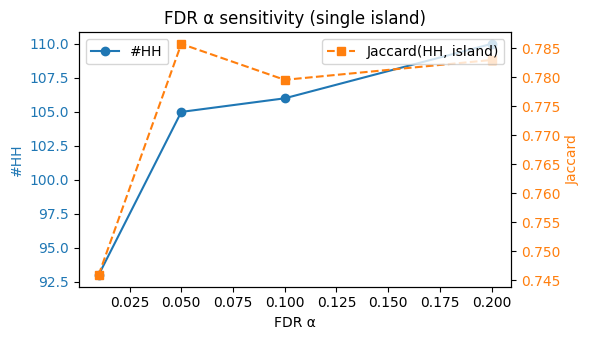

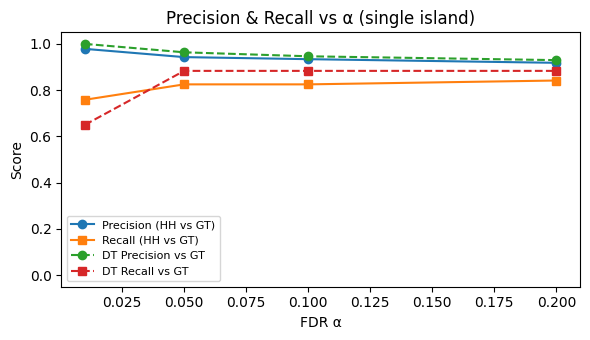

In [6]:
# FDR α sensitivity (Part A): same v, varying α
from sklearn.tree import DecisionTreeClassifier
X_test_2d_a = np.column_stack([X_test_raw["x1"].values, X_test_raw["x2"].values])
fdr_alphas = [0.01, 0.05, 0.10, 0.20]


def compute_single_island_fdr_sensitivity():
    rows = []
    for alpha in fdr_alphas:
        res = spatial_analysis(v, X_test, k=K_NN, fdr_alpha=alpha, seed=SEED)
        HH_a = res["HH_mask"]
        n_hh = int(HH_a.sum())
        lisa_df = pd.DataFrame({"cluster": np.where(HH_a, "HH", "NS")})
        W_sparse = res["W"].to_sparse() if hasattr(res["W"], "to_sparse") else res["W"].sparse
        _, comps = extract_hh_components(lisa_df, W_sparse, min_size=5)
        n_comp = len(comps)
        max_size = max(len(inds) for inds in comps.values()) if comps else 0
        tp_gt = (HH_a & island_test).sum()
        pred_pos = HH_a.sum()
        true_pos = island_test.sum()
        precision_gt = tp_gt / pred_pos if pred_pos else np.nan
        recall_gt = tp_gt / true_pos if true_pos else np.nan
        union = (HH_a | island_test).sum()
        jaccard = tp_gt / union if union else np.nan
        dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=SEED)
        dt.fit(X_test_2d_a, HH_a.astype(int))
        tree_pred = dt.predict(X_test_2d_a).astype(bool)
        dt_tp = (tree_pred & island_test).sum()
        dt_prec = dt_tp / tree_pred.sum() if tree_pred.sum() else np.nan
        dt_rec = dt_tp / true_pos if true_pos else np.nan
        rows.append({
            "α": alpha, "#HH": n_hh, "#components": n_comp, "max_component_size": max_size,
            "Jaccard": jaccard, "Precision": precision_gt, "Recall": recall_gt,
            "DT Precision": dt_prec, "DT Recall": dt_rec,
        })
    return pd.DataFrame(rows)


sens_df = load_or_compute_df(
    CACHE_DIR / f"nb08_single_island_fdr_{CACHE_VERSION}.parquet",
    compute_single_island_fdr_sensitivity,
    force=FORCE_RECOMPUTE,
)
print("FDR α sensitivity (single island):")
display(sens_df)

# Small figure: #HH and Jaccard vs α
fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.set_xlabel("FDR α")
ax1.plot(sens_df["α"], sens_df["#HH"], "o-", color="C0", label="#HH")
ax1.set_ylabel("#HH", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(sens_df["α"], sens_df["Jaccard"], "s--", color="C1", label="Jaccard(HH, island)")
ax2.set_ylabel("Jaccard", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.title("FDR α sensitivity (single island)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_fdr_sensitivity.pdf", bbox_inches="tight")
plt.show()
# Precision & Recall vs α (HH vs GT and DT vs GT)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.set_xlabel("FDR α")
ax.plot(sens_df["α"], sens_df["Precision"], "o-", label="Precision (HH vs GT)")
ax.plot(sens_df["α"], sens_df["Recall"], "s-", label="Recall (HH vs GT)")
ax.plot(sens_df["α"], sens_df["DT Precision"], "o--", label="DT Precision vs GT")
ax.plot(sens_df["α"], sens_df["DT Recall"], "s--", label="DT Recall vs GT")
ax.set_ylabel("Score")
ax.legend(loc="best", fontsize=8)
ax.set_ylim(-0.05, 1.05)
plt.title("Precision & Recall vs α (single island)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_fdr_sensitivity_prec_recall.pdf", bbox_inches="tight")
plt.show()


## 5. Visualize predictive variance and HH points

Test set in (x1, x2): color by pointwise variance; highlight HH hotspots. Optionally cluster and show variance / HH by cluster.

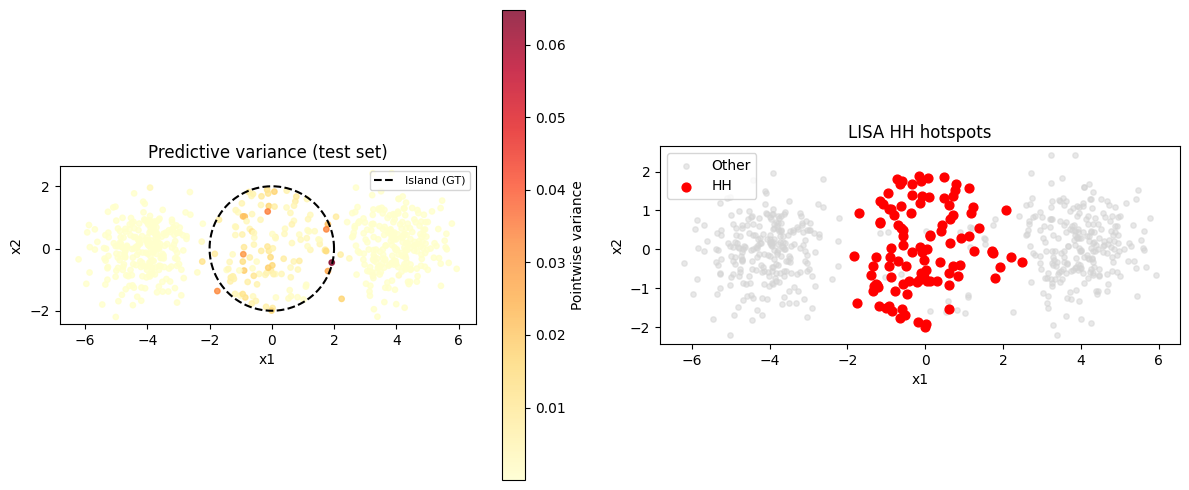

In [7]:
# Test set coordinates (original space for interpretability)
x1_test = X_test_raw["x1"].values
x2_test = X_test_raw["x2"].values
island_test = gt.island_mask[split["test"]]  # ground-truth ambiguous region on test set

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter colored by pointwise variance; overlay ground-truth island circle
sc = axes[0].scatter(x1_test, x2_test, c=v, s=15, cmap="YlOrRd", alpha=0.8)
theta = np.linspace(0, 2 * np.pi, 200)
axes[0].plot(gt.island_radius * np.cos(theta), gt.island_radius * np.sin(theta), "k--", lw=1.5, label="Island (GT)")
plt.colorbar(sc, ax=axes[0], label="Pointwise variance")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("Predictive variance (test set)")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_aspect("equal")

# Right: HH points highlighted
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5, label="Other")
axes[1].scatter(x1_test[HH_mask], x2_test[HH_mask], c="red", s=40, label="HH", zorder=5)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("LISA HH hotspots")
axes[1].legend()
axes[1].set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"single_island_pred_var_lisa.pdf", bbox_inches="tight")
plt.show()

## 6. Decision tree: HH vs non-HH

Fit a decision tree on (x1, x2) to predict HH vs non-HH. Interpretable boundaries show which region the tree associates with LISA hotspots.


Decision tree (HH vs non-HH) accuracy on test set: 0.9650
Feature importances (x1, x2): [0.98292237 0.01707763]


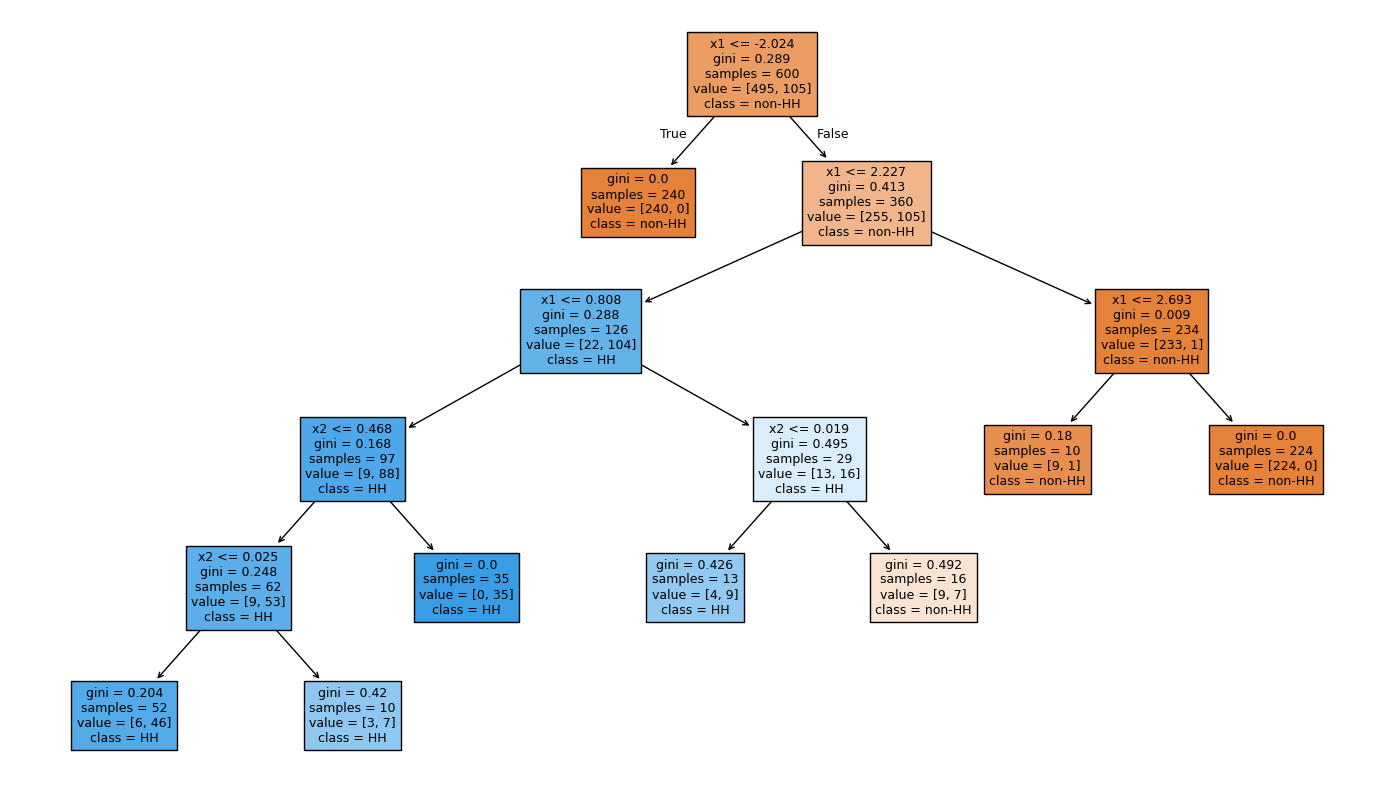

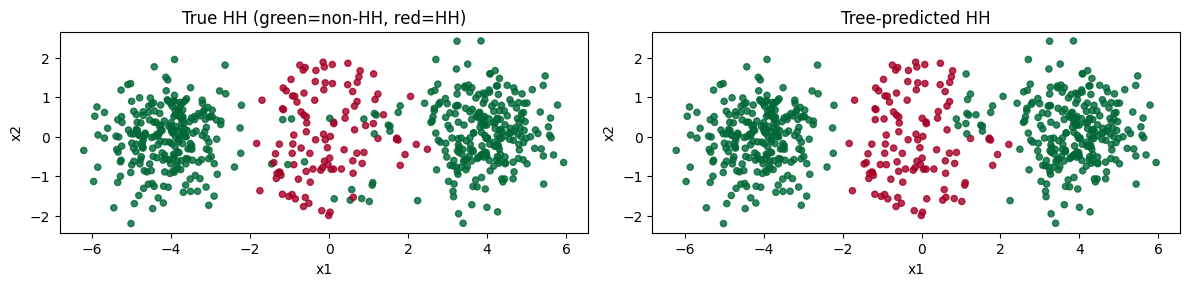

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

X_test_2d = np.column_stack([x1_test, x2_test])
y_hh = HH_mask.astype(int)  # 1 = HH, 0 = non-HH

dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=SEED)
dt.fit(X_test_2d, y_hh)
acc = dt.score(X_test_2d, y_hh)
print(f"Decision tree (HH vs non-HH) accuracy on test set: {acc:.4f}")
print("Feature importances (x1, x2):", dt.feature_importances_)

# Plot tree
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(dt, feature_names=["x1", "x2"], class_names=["non-HH", "HH"], filled=True, ax=ax, fontsize=9)
plt.tight_layout()
plt.show()

# Scatter: true HH vs tree-predicted HH
pred_hh = dt.predict(X_test_2d)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x1_test, x2_test, c=y_hh, s=20, cmap="RdYlGn_r", alpha=0.8)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("True HH (green=non-HH, red=HH)")
axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c=pred_hh, s=20, cmap="RdYlGn_r", alpha=0.8)
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("Tree-predicted HH")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()


## 7. Null experiment

Compare observed Moran's I to the null distribution (permuted predictions); plot histogram and empirical p-value.

Observed Moran's I: 0.2463
Null mean ± std: -0.0022 ± 0.0101
Empirical p-value (one-sided): 0.0099


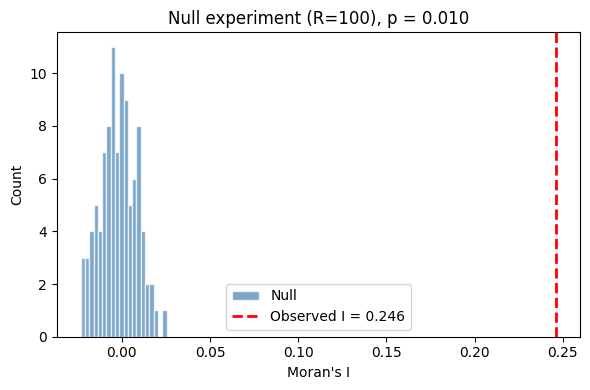

In [9]:
R_null = 100
null_res = run_null(run_dir, X_test, K=K_actual, R=R_null, k=K_NN, seed=SEED)
observed_I = spatial["moran_i"]
null_moran = null_res["null_moran_i"]
p_emp = (1 + np.sum(null_moran >= observed_I)) / (R_null + 1)

print(f"Observed Moran's I: {observed_I:.4f}")
print(f"Null mean ± std: {null_res['null_mean']:.4f} ± {null_res['null_std']:.4f}")
print(f"Empirical p-value (one-sided): {p_emp:.4f}")

plt.figure(figsize=(6, 4))
plt.hist(null_moran, bins=20, color="steelblue", alpha=0.7, edgecolor="white", label="Null")
plt.axvline(observed_I, color="red", linestyle="--", linewidth=2, label=f"Observed I = {observed_I:.3f}")
plt.xlabel("Moran's I")
plt.ylabel("Count")
plt.title(f"Null experiment (R={R_null}), p = {p_emp:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

---
## Part B: Three islands + outliers

Same pipeline on a second synthetic dataset: two stable blobs, **three** ambiguous islands, and isolated **outliers** (high-variance points that should not form HH clusters). Ground truth: `island_mask` (any of the 3 islands), `outlier_mask`, `stable_mask`.

In [10]:
from typing import Optional, List, Tuple, Dict
import numpy as np
import pandas as pd
from synthetic_data import _sample_uniform_disk, _weak_xor_probability


def make_synth_three_islands_plus_outliers(
    *,
    n_samples: int = 5000,
    p_islands: float = 0.30,
    p_outliers: float = 0.02,
    p_outliers_high_var: float = 0.50,
    stable_sep: float = 5.0,
    stable_std: float = 0.9,
    island_centers: Optional[List[Tuple[float, float]]] = None,
    island_radius: float = 2.0,
    island_delta: float = 0.30,
    outlier_box: Tuple[float, float, float, float] = (-20, 20, -15, 15),
    outlier_min_dist: float = 2.5,
    outlier_radius: float = 1.0,
    outlier_centers_high_var: Optional[List[Tuple[float, float]]] = None,
    outlier_centers_low_var: Optional[List[Tuple[float, float]]] = None,
    random_state: int = 0,
    shuffle: bool = True,
) -> Tuple[pd.DataFrame, pd.Series, Dict[str, list], "SyntheticGT"]:
    """
    Synthetic dataset with stable blobs, three ambiguous islands, and two types of outliers:

    - low-variance outliers: isolated points with stable label probability
    - high-variance outliers: small ambiguous mini-clusters with weak XOR structure

    Islands and high-variance outliers use a weak XOR signal (p=0.5 +/- delta),
    which creates genuine model disagreement: tree-based models can learn the XOR
    boundary while linear models predict ~0.5 locally.

    Ground truth:
        island_mask
        outlier_mask
        stable_mask
        p_true
        outlier_type  (-1 = not outlier, 0 = low-var outlier, 1 = high-var outlier)
    """
    if island_centers is None:
        island_centers = [(-6.0, 6.0), (6.0, 6.0), (0.0, -6.0)]
    if len(island_centers) != 3:
        raise ValueError("Provide exactly 3 island centers (or leave default).")
    if not (0.0 < island_delta < 0.5):
        raise ValueError("island_delta must be in (0, 0.5).")
    if not (0.0 <= p_outliers_high_var <= 1.0):
        raise ValueError("p_outliers_high_var must be in [0, 1].")

    if outlier_centers_high_var is None:
        # Chosen far from the stable blobs/islands and with opposite-sign geometry
        # so they are visually distinct and easy to interpret.
        outlier_centers_high_var = [(-18.0, 10.0), (18.0, -10.0)]

    if outlier_centers_low_var is None:
        # Chosen far away and near "stable side" regions where the label is clearer.
        outlier_centers_low_var = [(-18.0, -10.0), (18.0, 10.0)]

    rng = np.random.default_rng(random_state)
    n_out = int(round(n_samples * p_outliers))
    n_out_high = int(round(n_out * p_outliers_high_var))
    n_out_low = n_out - n_out_high

    n_islands_total = int(round(n_samples * p_islands))
    n_stable = n_samples - n_out - n_islands_total
    if n_stable <= 0:
        raise ValueError("Increase n_samples or reduce p_islands/p_outliers.")

    # ------------------------------------------------------------------
    # Stable blobs
    # ------------------------------------------------------------------
    n0 = n_stable // 2
    n1 = n_stable - n0
    X0 = rng.normal(loc=[-stable_sep, 0.0], scale=stable_std, size=(n0, 2))
    X1 = rng.normal(loc=[+stable_sep, 0.0], scale=stable_std, size=(n1, 2))
    y0 = np.zeros(n0, dtype=int)
    y1 = np.ones(n1, dtype=int)
    X_stable = np.vstack([X0, X1])
    y_stable = np.concatenate([y0, y1])
    p_true_stable = y_stable.astype(float)

    # ------------------------------------------------------------------
    # Three ambiguous islands (weak XOR)
    # ------------------------------------------------------------------
    n_each = [n_islands_total // 3] * 3
    n_each[-1] += n_islands_total - sum(n_each)

    X_islands = []
    y_islands = []
    p_true_islands = []
    island_id_islands = []

    for idx, (c, n_i) in enumerate(zip(island_centers, n_each)):
        Xi = _sample_uniform_disk(rng, n_i, island_radius, c)
        pi = _weak_xor_probability(Xi, island_delta, c)
        yi = rng.binomial(1, pi).astype(int)

        X_islands.append(Xi)
        y_islands.append(yi)
        p_true_islands.append(pi)
        island_id_islands.append(np.full(n_i, idx, dtype=int))

    X_islands = np.vstack(X_islands) if n_islands_total > 0 else np.zeros((0, 2))
    y_islands = np.concatenate(y_islands) if n_islands_total > 0 else np.zeros((0,), dtype=int)
    p_true_islands = np.concatenate(p_true_islands) if n_islands_total > 0 else np.zeros((0,), dtype=float)
    island_id_islands = np.concatenate(island_id_islands) if n_islands_total > 0 else np.zeros((0,), dtype=int)

    # ------------------------------------------------------------------
    # Outliers: LOW-VARIANCE type
    # ------------------------------------------------------------------
    # These are placed in small far-away regions and receive stable probabilities.
    # Left-side centers -> p_true = 0
    # Right-side centers -> p_true = 1
    # This makes it much clearer they should *not* be high-multiplicity hotspots.
    X_out_low = []
    p_true_out_low = []

    if n_out_low > 0:
        counts_low = [n_out_low // len(outlier_centers_low_var)] * len(outlier_centers_low_var)
        counts_low[-1] += n_out_low - sum(counts_low)

        for c, n_i in zip(outlier_centers_low_var, counts_low):
            Xi = _sample_uniform_disk(rng, n_i, outlier_radius, c)
            X_out_low.append(Xi)

            # Stable probability depending on side
            p_i = np.ones(n_i, dtype=float) if c[0] > 0 else np.zeros(n_i, dtype=float)
            p_true_out_low.append(p_i)

        X_out_low = np.vstack(X_out_low)
        p_true_out_low = np.concatenate(p_true_out_low)
        y_out_low = rng.binomial(1, p_true_out_low).astype(int)
    else:
        X_out_low = np.zeros((0, 2))
        p_true_out_low = np.zeros((0,), dtype=float)
        y_out_low = np.zeros((0,), dtype=int)

    # ------------------------------------------------------------------
    # Outliers: HIGH-VARIANCE type
    # ------------------------------------------------------------------
    # These are small ambiguous mini-clusters using the same weak XOR mechanism
    # as the islands, so they are intended to be true localized high-multiplicity areas.
    X_out_high = []
    p_true_out_high = []

    if n_out_high > 0:
        counts_high = [n_out_high // len(outlier_centers_high_var)] * len(outlier_centers_high_var)
        counts_high[-1] += n_out_high - sum(counts_high)

        for c, n_i in zip(outlier_centers_high_var, counts_high):
            Xi = _sample_uniform_disk(rng, n_i, outlier_radius, c)
            pi = _weak_xor_probability(Xi, island_delta, c)

            X_out_high.append(Xi)
            p_true_out_high.append(pi)

        X_out_high = np.vstack(X_out_high)
        p_true_out_high = np.concatenate(p_true_out_high)
        y_out_high = rng.binomial(1, p_true_out_high).astype(int)
    else:
        X_out_high = np.zeros((0, 2))
        p_true_out_high = np.zeros((0,), dtype=float)
        y_out_high = np.zeros((0,), dtype=int)

    # ------------------------------------------------------------------
    # Combine outliers
    # ------------------------------------------------------------------
    X_out = np.vstack([X_out_low, X_out_high])
    p_true_out = np.concatenate([p_true_out_low, p_true_out_high])
    y_out = np.concatenate([y_out_low, y_out_high])

    outlier_type = np.concatenate([
        np.full(n_stable + n_islands_total, -1, dtype=int),   # not outlier
        np.zeros(len(X_out_low), dtype=int),                  # low-var outlier
        np.ones(len(X_out_high), dtype=int),                  # high-var outlier
    ])

    # ------------------------------------------------------------------
    # Combine all data
    # ------------------------------------------------------------------
    X_all = np.vstack([X_stable, X_islands, X_out])
    y_all = np.concatenate([y_stable, y_islands, y_out])
    p_true_all = np.concatenate([p_true_stable, p_true_islands, p_true_out])

    island_id = np.concatenate([
        np.full(n_stable, -1, dtype=int),
        island_id_islands,
        np.full(len(X_out), 99, dtype=int),
    ])

    island_mask = (island_id >= 0) & (island_id <= 2)
    outlier_mask = (island_id == 99)
    stable_mask = (island_id == -1)

    if shuffle:
        perm = rng.permutation(len(X_all))
        X_all = X_all[perm]
        y_all = y_all[perm]
        p_true_all = p_true_all[perm]
        island_id = island_id[perm]
        island_mask = island_mask[perm]
        outlier_mask = outlier_mask[perm]
        stable_mask = stable_mask[perm]
        outlier_type = outlier_type[perm]

    X = pd.DataFrame(X_all, columns=["x1", "x2"])
    y = pd.Series(y_all, name="target")
    feature_info = {"numeric": ["x1", "x2"], "categorical": []}

    gt = SyntheticGT(
    island_id=island_id,
    island_mask=island_mask,
    outlier_mask=outlier_mask,
    stable_mask=stable_mask,
    p_true=p_true_all,
    island_centers=island_centers,
    island_radius=island_radius,
)
    return X, y, feature_info, gt

Samples: 5000, island: 1500, stable: 3400, outliers: 100


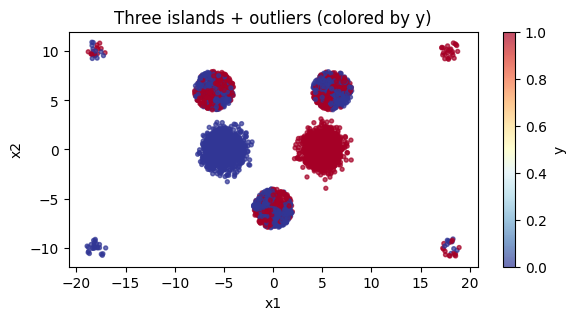

In [11]:
# Dataset 2: three islands + outliers
# (increased n_samples for more per-island mass, higher delta for stronger
#  model disagreement, islands spread further apart to avoid interference)
X, y, feature_info, gt = make_synth_three_islands_plus_outliers(
    n_samples=5000,
    p_islands=0.30,
    p_outliers=0.02,
    island_delta=0.30,
    random_state=SEED,
)
print(f"Samples: {len(X)}, island: {gt.island_mask.sum()}, stable: {gt.stable_mask.sum()}, outliers: {gt.outlier_mask.sum()}")

plt.figure(figsize=(6, 5))
plt.scatter(X["x1"], X["x2"], c=y, s=8, alpha=0.7, cmap="RdYlBu_r")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Three islands + outliers (colored by y)")
plt.colorbar(label="y", shrink=0.5)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_ground_truth.pdf", bbox_inches="tight")
plt.show()

In [12]:
# Train and save to a separate run dir
run_dir = RESULTS_DIR / "synthetic_three_islands" / f"seed={SEED}"
run_dir.mkdir(parents=True, exist_ok=True)

preprocessor_factory = lambda fi: make_preprocessor(fi, scale_numeric=True)
split, meta, P_val, P_test, _ = run_one_training_run(
    X=X, y=y, feature_info=feature_info, preprocessor_factory=preprocessor_factory,
    outer_seed=SEED, n_candidates_per_family=50, test_size=0.2, val_size=0.2, verbose=1,
)
save_run_artifacts(run_dir, split, meta, P_val, P_test, config={"dataset": "synthetic_three_islands", "seed": SEED})

preprocessor = preprocessor_factory(feature_info)
preprocessor.fit(X.iloc[split["train"]], y.iloc[split["train"]])
X_test_raw = X.iloc[split["test"]]
X_test = np.asarray(preprocessor.transform(X_test_raw))
print(f"Saved to {run_dir}, test size: {X_test.shape[0]}")

  [LogReg] 50 candidates trained


  [kNN] 50 candidates trained


  [RF] 50 candidates trained


  [GBM] 50 candidates trained


  [MLP] 50 candidates trained
Saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\synthetic_three_islands\seed=42, test size: 1000


In [13]:
# Rashomon + spatial
n_cand = len(load_meta(run_dir))
K_actual = min(K, n_cand)
spatial = run_spatial(run_dir, X_test, K=K_actual, k=K_NN)
mult = compute_multiplicity_metrics(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], epsilon=0.05)
v = pointwise_variance(load_P_test(run_dir)[select_rashomon_global(run_dir, K=K_actual)], ddof=0)
HH_mask = spatial["HH_mask"]
LL_mask = spatial["LL_mask"]
print(f"Moran's I: {spatial['moran_i']:.4f}, mean variance: {mult['mean_variance']:.6f}, HH: {HH_mask.sum()}, LL: {LL_mask.sum()}")

C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The we

Moran's I: 0.4215, mean variance: 0.001076, HH: 268, LL: 671


In [14]:
# Recovery: HH vs ground-truth island (any of the 3 islands)
test_idx = split["test"]
island_test = gt.island_mask[test_idx]
tp = (HH_mask & island_test).sum()
pred_pos = HH_mask.sum()
true_pos = island_test.sum()
precision = tp / pred_pos if pred_pos else np.nan
recall = tp / true_pos if true_pos else np.nan
union = (HH_mask | island_test).sum()
jaccard = tp / union if union else np.nan
print("Recovery of ground-truth islands by LISA HH:")
print(f"  Precision: {precision:.4f}, Recall: {recall:.4f}, Jaccard: {jaccard:.4f}")
print(f"  TP={int(tp)}, |HH|={int(pred_pos)}, |island|={int(true_pos)}")

Recovery of ground-truth islands by LISA HH:
  Precision: 0.9627, Recall: 0.8776, Jaccard: 0.8487
  TP=258, |HH|=268, |island|=294


### FDR α sensitivity (three islands)

Same sensitivity: α ∈ {0.01, 0.05, 0.10, 0.20} → #HH, #components, max component size, Jaccard(HH, GT island); Precision & Recall (HH vs GT); DT Precision & DT Recall (tree vs GT).

C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


FDR α sensitivity (three islands):


C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)


,α,#HH,#components,max_component_size,Jaccard,Precision,Recall,DT Precision,DT Recall
0,0.01,267,3,101,0.845395,0.962547,0.874150,0.978571,0.931973
1,0.05,268,3,101,0.848684,0.962687,0.877551,0.978571,0.931973
2,0.10,268,3,101,0.848684,0.962687,0.877551,0.978571,0.931973
3,0.20,269,3,101,0.845902,0.959108,0.877551,0.978571,0.931973


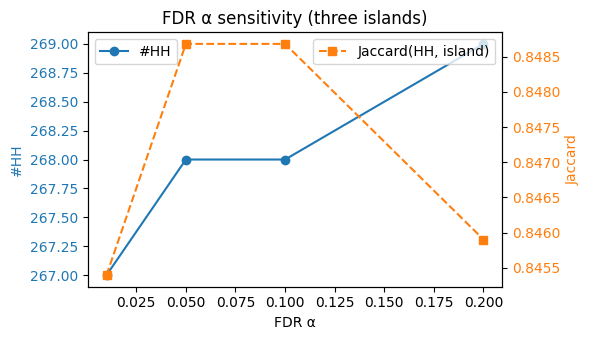

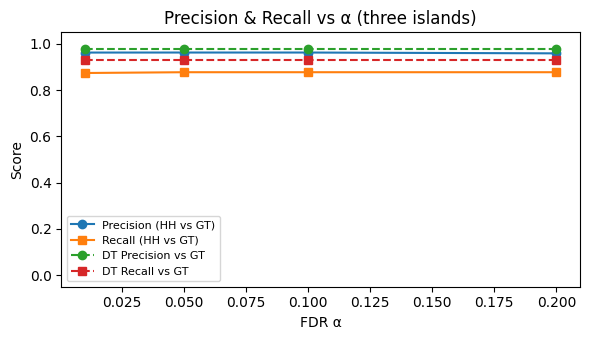

In [15]:
# FDR α sensitivity (Part B)
from sklearn.tree import DecisionTreeClassifier
X_test_2d_b = np.column_stack([X_test_raw["x1"].values, X_test_raw["x2"].values])


def compute_three_islands_fdr_sensitivity():
    rows = []
    for alpha in fdr_alphas:
        res = spatial_analysis(v, X_test, k=K_NN, fdr_alpha=alpha, seed=SEED)
        HH_a = res["HH_mask"]
        n_hh = int(HH_a.sum())
        lisa_df = pd.DataFrame({"cluster": np.where(HH_a, "HH", "NS")})
        W_sparse = res["W"].to_sparse() if hasattr(res["W"], "to_sparse") else res["W"].sparse
        _, comps = extract_hh_components(lisa_df, W_sparse, min_size=5)
        n_comp = len(comps)
        max_size = max(len(inds) for inds in comps.values()) if comps else 0
        tp_gt = (HH_a & island_test).sum()
        pred_pos = HH_a.sum()
        true_pos = island_test.sum()
        precision_gt = tp_gt / pred_pos if pred_pos else np.nan
        recall_gt = tp_gt / true_pos if true_pos else np.nan
        union = (HH_a | island_test).sum()
        jaccard = tp_gt / union if union else np.nan
        dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=SEED)
        dt.fit(X_test_2d_b, HH_a.astype(int))
        tree_pred = dt.predict(X_test_2d_b).astype(bool)
        dt_tp = (tree_pred & island_test).sum()
        dt_prec = dt_tp / tree_pred.sum() if tree_pred.sum() else np.nan
        dt_rec = dt_tp / true_pos if true_pos else np.nan
        rows.append({
            "α": alpha, "#HH": n_hh, "#components": n_comp, "max_component_size": max_size,
            "Jaccard": jaccard, "Precision": precision_gt, "Recall": recall_gt,
            "DT Precision": dt_prec, "DT Recall": dt_rec,
        })
    return pd.DataFrame(rows)


sens_df_b = load_or_compute_df(
    CACHE_DIR / f"nb08_three_islands_fdr_{CACHE_VERSION}.parquet",
    compute_three_islands_fdr_sensitivity,
    force=FORCE_RECOMPUTE,
)
print("FDR α sensitivity (three islands):")
display(sens_df_b)

fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.set_xlabel("FDR α")
ax1.plot(sens_df_b["α"], sens_df_b["#HH"], "o-", color="C0", label="#HH")
ax1.set_ylabel("#HH", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.plot(sens_df_b["α"], sens_df_b["Jaccard"], "s--", color="C1", label="Jaccard(HH, island)")
ax2.set_ylabel("Jaccard", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.title("FDR α sensitivity (three islands)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_fdr_sensitivity.pdf", bbox_inches="tight")
plt.show()
# Precision & Recall vs α (three islands)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.set_xlabel("FDR α")
ax.plot(sens_df_b["α"], sens_df_b["Precision"], "o-", label="Precision (HH vs GT)")
ax.plot(sens_df_b["α"], sens_df_b["Recall"], "s-", label="Recall (HH vs GT)")
ax.plot(sens_df_b["α"], sens_df_b["DT Precision"], "o--", label="DT Precision vs GT")
ax.plot(sens_df_b["α"], sens_df_b["DT Recall"], "s--", label="DT Recall vs GT")
ax.set_ylabel("Score")
ax.legend(loc="best", fontsize=8)
ax.set_ylim(-0.05, 1.05)
plt.title("Precision & Recall vs α (three islands)")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_fdr_sensitivity_precision_recall.pdf", bbox_inches="tight")
plt.show()


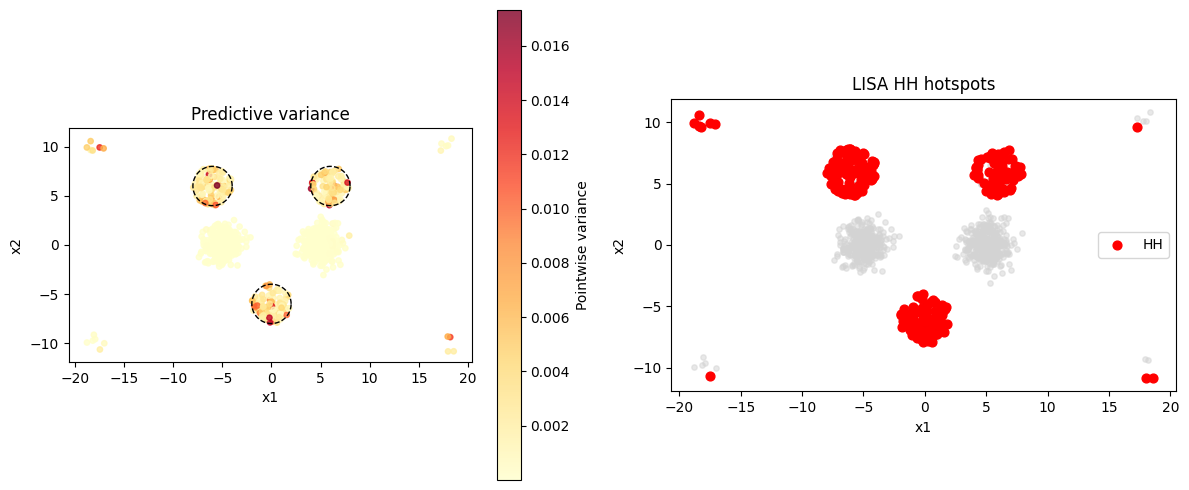

In [16]:
# Visualize variance and HH (three islands)
x1_test = X_test_raw["x1"].values
x2_test = X_test_raw["x2"].values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc = axes[0].scatter(x1_test, x2_test, c=v, s=15, cmap="YlOrRd", alpha=0.8)
for c in gt.island_centers:
    theta = np.linspace(0, 2 * np.pi, 200)
    axes[0].plot(gt.island_radius * np.cos(theta) + c[0], gt.island_radius * np.sin(theta) + c[1], "k--", lw=1)
plt.colorbar(sc, ax=axes[0], label="Pointwise variance")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_title("Predictive variance"); axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[1].scatter(x1_test[HH_mask], x2_test[HH_mask], c="red", s=40, label="HH", zorder=5)
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].set_title("LISA HH hotspots"); axes[1].legend(); axes[1].set_aspect("equal")
plt.tight_layout()
plt.savefig(FIG_DIR / f"three_islands_pred_var_lisa.pdf", bbox_inches="tight")
plt.show()

Decision tree accuracy (HH vs non-HH): 0.9600


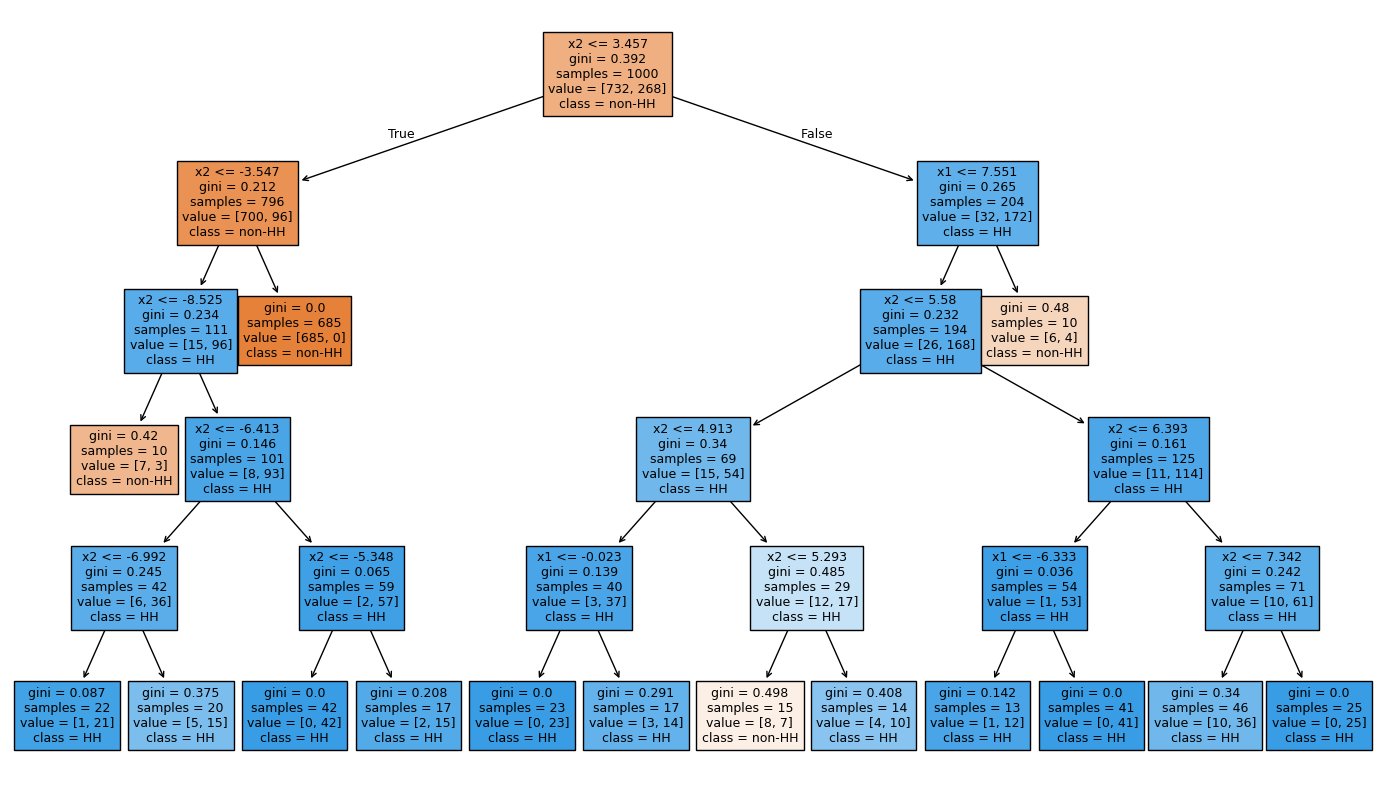

In [17]:
# Decision tree: HH vs non-HH (three islands)
from sklearn.tree import DecisionTreeClassifier, plot_tree
X_test_2d = np.column_stack([x1_test, x2_test])
y_hh = HH_mask.astype(int)
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=SEED)
dt.fit(X_test_2d, y_hh)
print(f"Decision tree accuracy (HH vs non-HH): {dt.score(X_test_2d, y_hh):.4f}")
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(dt, feature_names=["x1", "x2"], class_names=["non-HH", "HH"], filled=True, ax=ax, fontsize=9)
plt.tight_layout()
plt.show()

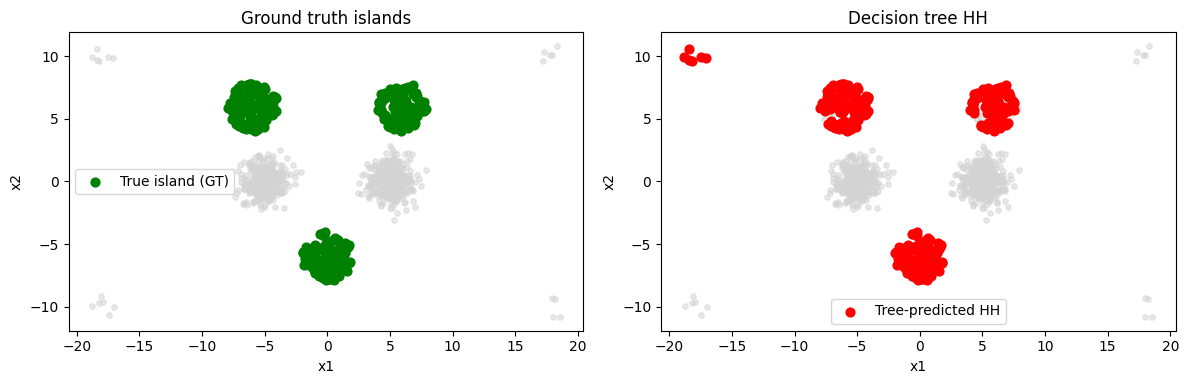

In [18]:
# Scatter: true HH (island) vs tree-predicted HH (three islands)
hh_pred = dt.predict(X_test_2d).astype(bool)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[0].scatter(x1_test[island_test], x2_test[island_test], c="green", s=40, label="True island (GT)", zorder=5)
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_title("Ground truth islands"); axes[0].legend(); axes[0].set_aspect("equal")
axes[1].scatter(x1_test, x2_test, c="lightgray", s=15, alpha=0.5)
axes[1].scatter(x1_test[hh_pred], x2_test[hh_pred], c="red", s=40, label="Tree-predicted HH", zorder=5)
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].set_title("Decision tree HH"); axes[1].legend(); axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\weights.py:1294: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  out_w = W(neighbors, weights, id_order=self.id_order)


Observed Moran's I: 0.4215, null mean±std: -0.0001 ± 0.0077, p = 0.0099


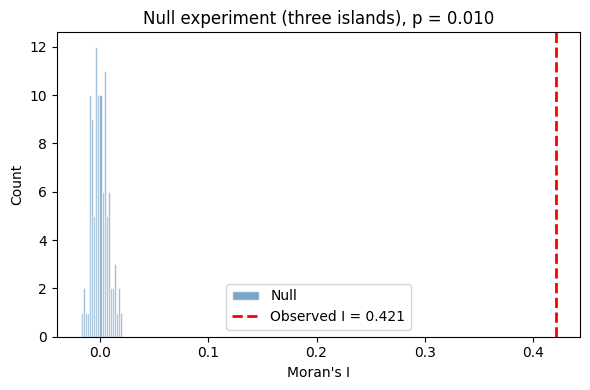

In [19]:
# Null experiment (three islands)
null_res = run_null(run_dir, X_test, K=K_actual, R=100, k=K_NN, seed=SEED)
observed_I = spatial["moran_i"]
null_moran = null_res["null_moran_i"]
p_emp = (1 + np.sum(null_moran >= observed_I)) / 101
print(f"Observed Moran's I: {observed_I:.4f}, null mean±std: {null_res['null_mean']:.4f} ± {null_res['null_std']:.4f}, p = {p_emp:.4f}")
plt.figure(figsize=(6, 4))
plt.hist(null_moran, bins=20, color="steelblue", alpha=0.7, edgecolor="white", label="Null")
plt.axvline(observed_I, color="red", linestyle="--", linewidth=2, label=f"Observed I = {observed_I:.3f}")
plt.xlabel("Moran's I"); plt.ylabel("Count"); plt.title(f"Null experiment (three islands), p = {p_emp:.3f}"); plt.legend()
plt.tight_layout()
plt.show()